For Figure 3 D predicted y-positions in inset

In [1]:
# imports
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge, RidgeCV
import scipy.stats 
from scipy.stats import sem, pearsonr, zscore, shapiro, levene, wilcoxon

import sys
sys.path.append('../util_code')

from functions import neuron_reliability, reliability_filtering, regression_indices, model_reliability_2, convert_to_deg


In [2]:
# import data files from Pico and Kenny
p_file = h5py.File('../data/neural/230801.m1.rsvp.gratingsAdap_s5.experiment_psth_raw.h5','r')
k_file = h5py.File('../data/neural/m2_season5.mat','r')

p_rates = p_file['/psth'][:]
k_rates = k_file['/rates'][:]

In [3]:
# load the ground truth center positions in pixel space 
human_im_size = 268.51895786308
gt_im_size = 256
df = pd.read_csv('../data/mae_s5_coordinates.csv') # position data
pos = np.squeeze(df['center_y'].values.reshape(-1,1))*(human_im_size/gt_im_size) # convert to the dimensions of the image that the humans made estimates on

# convert labels to eccentricity 
pos = convert_to_deg(pos, human_im_size)

In [4]:
# getting 70-170 ms and reshaping for S5 Pico and Kenny
s5_neural_pico = np.transpose(np.nanmean(p_rates[:,:,7:17,:],axis=2), (0,2,1)) # gets the neural data for 70-170 ms only, raised a mean of an empty slice warning bc last couple of reps are empty
s5_neural_kenny = k_rates

/tmp/ipykernel_1432175/3951971199.py:2: RuntimeWarning: Mean of empty slice
  s5_neural_pico = np.transpose(np.nanmean(p_rates[:,:,7:17,:],axis=2), (0,2,1)) # gets the neural data for 70-170 ms only, raised a mean of an empty slice warning bc last couple of reps are empty


In [5]:
# concatenate Pico and Kenny's data along the units axis
s5_neural = np.concatenate((s5_neural_pico,s5_neural_kenny), axis=1)

In [6]:
# get the neuron reliabilities for 70-170 ms
rel, std_rel = neuron_reliability(s5_neural)

In [7]:
# filter neurons to include only those with r > 0.2
s5_neural = reliability_filtering(s5_neural,rel,metric=0.2)

In [8]:
# normalize the results across all the units (axis = 1) - in the combined population because we want one distribution
s5_neural = zscore(s5_neural,axis=1)

In [9]:
# reduce dimensionality for making preds, no more repetitions
s5_neural_for_preds = np.nanmean(s5_neural,axis=2)

In [10]:
# train the decoder on s5 data 
n_img = 40
n_reps = 100
n_folds = 4
alpha_values = [0.01, 0.1, 1, 10, 100]
s5_regressors = {}
s5_reg_rels = np.empty((n_reps,n_folds))
s5_em_array= np.empty((n_img,n_reps)) # 40 images by 100 predictions per image
for x in range(n_reps):
    for i in range(n_folds):
        train, test = regression_indices(n_img, number_of_groups=4, test_group=i, SEED=x)
        x_train = s5_neural_for_preds[train,:]
        y_train = pos[train]
        x_test = s5_neural_for_preds[test,:]
        ridge_cv = RidgeCV(alphas=alpha_values).fit(x_train,y_train) # performs leave-one-out cross validated alpha optimization
        best_alpha = ridge_cv.alpha_
        s5_regressors[f"reg_{x}_{i}"] = Ridge(alpha=best_alpha) 
        s5_regressors[f"reg_{x}_{i}"].fit(x_train,y_train)
        y_pred = s5_regressors[f"reg_{x}_{i}"].predict(x_test)
        s5_em_array[test, x] = np.squeeze(y_pred)
        s5_reg_rels[x,i] = model_reliability_2(s5_neural, s5_regressors[f"reg_{x}_{i}"], test)

In [11]:
#load and format S3 and S4 for both Pico and Kenny
p_file_s3 = h5py.File('../data/neural/230801.m1.rsvp.gratingsAdap_s3.experiment_psth_raw.h5','r')
p_file_s4 = h5py.File('../data/neural/230801.m1.rsvp.gratingsAdap_s4.experiment_psth_raw.h5','r')
k_file_s3 = h5py.File('../data/neural/m2_season3.mat','r')
k_file_s4 = h5py.File('../data/neural/m2_season4.mat','r')

p_rates_s3 = p_file_s3['/psth'][:]
p_rates_s4 = p_file_s4['/psth'][:]
k_rates_s3 = k_file_s3['/kenny_s3'][:]
k_rates_s4 = k_file_s4['/kenny_s4'][:]

In [12]:
# getting 70-170 ms after test stimulus onset for S1-4 for Pico and Kenny
s3_neural_pico = np.transpose(np.nanmean(p_rates_s3[:,:,337:347,:],axis=2), (0,2,1)) 
s4_neural_pico = np.transpose(np.nanmean(p_rates_s4[:,:,337:347,:],axis=2), (0,2,1)) 
s3_neural_kenny = k_rates_s3
s4_neural_kenny = k_rates_s4

In [13]:
# concatenate Pico and Kenny data along units, and filter for only reliable units 
s3_neural = reliability_filtering(np.concatenate((s3_neural_pico,s3_neural_kenny),axis=1),rel,metric=0.2)
s4_neural = reliability_filtering(np.concatenate((s4_neural_pico,s4_neural_kenny),axis=1),rel,metric=0.2)

In [14]:
# z-scoring across units 
s3_neural = zscore(s3_neural, axis=1)
s4_neural = zscore(s4_neural, axis=1)

In [15]:
# preparing the data for making predictions
s3_neural_for_preds = np.nanmean(s3_neural,axis=2)
s4_neural_for_preds = np.nanmean(s4_neural,axis=2)

In [16]:
# function for making predictions 
def seasons_preds(neural,best_rep):
    reg_rels = np.empty((n_reps,n_folds))
    season_rates = np.nanmean(neural,axis=2)
    em_array= np.empty((n_img,n_reps))
    for x in range(n_reps):
        for i in range(n_folds):
            test = regression_indices(n_img, number_of_groups=n_folds, test_group= i, SEED= x)[1] # use the function in functions.py to get the indices (i.e., the identifier of the images) in the train and test set
            X_test = season_rates[test,:] # index the neural data for the images used for testing from the neural variable
            y_pred = s5_regressors[f"reg_{x}_{i}"].predict(X_test)
            reg_rels[x,i] = model_reliability_2(neural, s5_regressors[f"reg_{x}_{i}"], test)
            em_array[test,x] = np.squeeze(y_pred)
    s_preds = np.nanmean(em_array[:,:best_rep], axis=1) # get correlation only up to the best rep
    s_preds_std = np.nanstd(em_array[:,:best_rep], axis=1)
    corr = np.empty(best_rep) 
    for p in range(best_rep): # edited to be correlation with s5 predictions
        corr_temp = pearsonr(s5_em_array[:,p], em_array[:,p])[0] # correlate the predictions from each shuffle with s5 preds
        corr[p] = corr_temp/np.sqrt(np.nanmean(reg_rels,axis=1)[p])
    s_corr = np.nanmean(corr)
    s_corr_std = np.nanstd(corr)
    return corr, s_preds, s_preds_std, s_corr, s_corr_std, em_array

In [17]:
# getting the predictions for each season
full_s3x_corr, s3_preds, s3_preds_std, s3_corr, s3_corr_std, s3_pred_array = seasons_preds(s3_neural,100)
full_s4x_corr, s4_preds, s4_preds_std, s4_corr, s4_corr_std, s4_pred_array = seasons_preds(s4_neural,100)

In [18]:
# save the predictions to use in figure 3
np.save('../data/s3y_neural_pred_array.npy', s3_pred_array)
np.save('../data/s4y_neural_pred_array.npy', s4_pred_array)

In [19]:
# plotting range
pos_range = np.linspace(min(pos),max(pos))

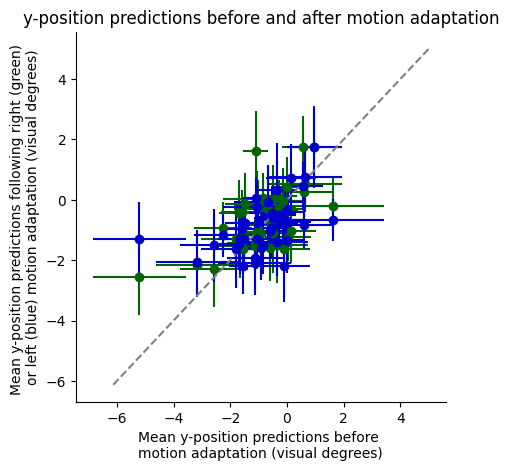

In [20]:
# s3 vs s4 predictions
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

best_rep = 100
s5_preds = np.nanmean(s5_em_array[:,:best_rep],axis=1)
s5_preds_std = np.nanstd(s5_em_array[:,:best_rep],axis=1)

plt.errorbar(s5_preds,s3_preds,xerr=s5_preds_std,yerr=s3_preds_std, fmt='o', color='darkgreen') # rightward motion
plt.errorbar(s5_preds,s4_preds,xerr=s5_preds_std,yerr=s4_preds_std, fmt='o', color='mediumblue') # leftward motion
plt.plot(pos_range,pos_range, color='grey', linestyle='--')

plt.xlabel('Mean y-position predictions before \nmotion adaptation (visual degrees)')
plt.ylabel('Mean y-position predictions following right (green) \nor left (blue) motion adaptation (visual degrees)')
plt.title('y-position predictions before and after motion adaptation')

x0,x1 = plt.gca().get_xlim()
y0,y1 = plt.gca().get_ylim()

plt.gca().set_aspect(abs(x1-x0)/abs(y1-y0))

# plt.savefig('/home/eyakub/scratch/y_s34.eps', format='eps', bbox_inches='tight')